# EDA and Feature Engineering of Google Playstore Dataset

Problem Statement: To explore the Google Play Store dataset to identify key trends and patterns in app distribution, pricing, popularity, and user engagement, and understand what factors influence app success.

Steps we are going to Follow:-

1. Data Cleaning
2. Exploratory Data Analysis
3. Feature Engineering

## 1) Loading Data and Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv")
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
# Saving the raw dataset to CSV file
df.to_csv("google_playstore_raw.csv",index=False)

## 2) Characteristics of Data

In [4]:
df.shape

(10841, 13)

The dataset consists of 10841 rows and 13 columns. The columns are:-

In [5]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

Datatypes of columns:-

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


Statistical Description of numerical data:-

In [7]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


## 3) Data Checks To Perform and Fix Issues

### 3.1. Check Missing Values

In [8]:
df.isnull().sum()   

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

We have 1474 missing values in 'Rating', 1 in 'Type', 1 in 'Content Rating', 8 in 'Current Ver' and 3 in 'Android Ver' columns.

Lets fix them one-by-one in each column!

In [9]:
# Median Imputation to fill missing values in Rating

median_rating = df[df['Rating'].notna()]['Rating'].median()   
print("Median Rating to impute: ",median_rating)

df.fillna({'Rating':median_rating},inplace=True)    # for null values

print("Median Imputation in Ratings done!")

Median Rating to impute:  4.3
Median Imputation in Ratings done!


In [10]:
df['Rating'].unique()

array([ 4.1,  3.9,  4.7,  4.5,  4.3,  4.4,  3.8,  4.2,  4.6,  3.2,  4. ,
        4.8,  4.9,  3.6,  3.7,  3.3,  3.4,  3.5,  3.1,  5. ,  2.6,  3. ,
        1.9,  2.5,  2.8,  2.7,  1. ,  2.9,  2.3,  2.2,  1.7,  2. ,  1.8,
        2.4,  1.6,  2.1,  1.4,  1.5,  1.2, 19. ])

In [11]:
df['Type'].unique()

array(['Free', 'Paid', nan, '0'], dtype=object)

In [12]:
df[df['Type'].isna()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
9148,Command & Conquer: Rivals,FAMILY,4.3,0,Varies with device,0,NaN,0,Everyone 10+,Strategy,"June 28, 2018",Varies with device,Varies with device


In [13]:
df['Type'].value_counts()

Type
Free    10039
Paid      800
0           1
Name: count, dtype: int64

In [14]:
df['Type'].fillna('Free',inplace=True)         # Replacing mode of 'Type' (Free) with nan

df['Type'] = df['Type'].apply(lambda x: 'Free' if x=='0' else x)    # Substituting 0 with Free

print("Type Imputation done!")

Type Imputation done!


In [15]:
df['Content Rating'].unique()

array(['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+', 'Unrated', nan], dtype=object)

In [16]:
mode_content_rating = df[df['Content Rating'].notna()]['Content Rating'].mode()[0]
print('Mode Content Rating is: ',mode_content_rating)

df['Content Rating'].fillna(df['Content Rating'].mode()[0], inplace=True)
print("Content Rating Imputation done!")

Mode Content Rating is:  Everyone
Content Rating Imputation done!


In [17]:
mode_current_version = df[df['Current Ver'].notna()]['Current Ver'].mode()[0]
print('Mode Current Version is: ',mode_current_version)

df['Current Ver'].fillna(df['Current Ver'].mode()[0], inplace=True)
print("Current Ver Imputation done!")

Mode Current Version is:  Varies with device
Current Ver Imputation done!


In [18]:
mode_android_version = df[df['Android Ver'].notna()]['Android Ver'].mode()[0]
print('Mode Android Version is: ',mode_android_version)

df['Android Ver'].fillna(df['Android Ver'].mode()[0], inplace=True)
print("Android Ver Imputation done!")

Mode Android Version is:  4.1 and up
Android Ver Imputation done!


In [19]:
#Checking for null values again
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

Now, we have no missing values in the dataset. Let's check for duplicates.

### 3.2. Check Duplicates

In [20]:
df[df['App']=='Box'] #Example of duplicates

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
204,Box,BUSINESS,4.2,159872,Varies with device,"10,000,000+",Free,0,Everyone,Business,"July 31, 2018",Varies with device,Varies with device
236,Box,BUSINESS,4.2,159872,Varies with device,"10,000,000+",Free,0,Everyone,Business,"July 31, 2018",Varies with device,Varies with device
265,Box,BUSINESS,4.2,159872,Varies with device,"10,000,000+",Free,0,Everyone,Business,"July 31, 2018",Varies with device,Varies with device


In [21]:
df.duplicated('App').sum()

1181

We have duplication in App names which we treat as our primary key. So we drop them.

In [22]:
df.drop_duplicates(subset=['App'],keep='first',inplace=True)

In [23]:
df.shape

(9660, 13)

### 3.3. Check Unique Values

In [24]:
df.nunique()    # Number of unique values in each column

App               9660
Category            34
Rating              40
Reviews           5331
Size               462
Installs            22
Type                 2
Price               93
Content Rating       6
Genres             119
Last Updated      1378
Current Ver       2818
Android Ver         33
dtype: int64

In [25]:
for col in df.columns:
    print(f"Unique values of column '{col}':\n")
    print(df[col].unique())
    print('\n','-'*50,'\n')

Unique values of column 'App':

['Photo Editor & Candy Camera & Grid & ScrapBook' 'Coloring book moana'
 'U Launcher Lite – FREE Live Cool Themes, Hide Apps' ...
 'Parkinson Exercices FR' 'The SCP Foundation DB fr nn5n'
 'iHoroscope - 2018 Daily Horoscope & Astrology']

 -------------------------------------------------- 

Unique values of column 'Category':

['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION' '1.9']

 -------------------------------------------------- 

Unique values of column 'Rating':

[ 4.1  3.9  4.7  4.5  4.3  4.4  3.8  4.2  4.6  3.2  4.   4.8  4.9  3.6
  3.7

## 4) Data Preprocessing and Cleaning

Observed the dataset thoroughly and discovered some inconsistentencies in data and values. Let's see them!

In [26]:
# Found outliers in some columns, fixing them with mode values of columns

df['Rating'] = df['Rating'].apply(lambda x: median_rating if x==19. else x)  

mode_category = df[df['Category'].notna()]['Category'].mode()[0]
df['Category'] = df['Category'].apply(lambda x: mode_category if x=='1.9' else x)   

mode_genre = df[df['Genres'].notna()]['Genres'].mode()[0]
df['Genres'] = df['Genres'].apply(lambda x: mode_genre if x=='February 11, 2018' else x)   

We resolved the outliers now.

In [27]:
# Checking whether Reviews is numeric or not
df['Reviews'].str.isnumeric().sum()

9659

This means there is one record with non-numeric value in Reviews column.

In [28]:
df[df['Reviews'].str.isnumeric()==False]    # Here there is one such record

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,FAMILY,4.3,3.0M,"1,000+",Free,Free,Everyone,Everyone,Tools,1.0.19,4.0 and up,4.1 and up


In [29]:
#Converting that review to numeric string

df['Reviews'] = df['Reviews'].apply(lambda x: '3000000' if x=='3.0M' else x)
df['Reviews'].str.isnumeric().sum()

9660

In [30]:
#Convert Reviews datatype to int
df['Reviews'] = df['Reviews'].astype(int)
df['Reviews'].dtype

dtype('int32')

In [31]:
#On examining Size column, we can convert Size column into numerical feature by processing the values 
df['Size'].unique()  #We have one categorical value as "Varies wth device"

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [32]:
df[df['Size']=='Varies with device']['Size'].value_counts()

Size
Varies with device    1227
Name: count, dtype: int64

In [33]:
df[df['Size'].str.endswith('+')]    # Only one such record with + sign

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,FAMILY,4.3,3000000,"1,000+",Free,Free,Everyone,Everyone,Tools,1.0.19,4.0 and up,4.1 and up


In [34]:
# Function to convert Size column to numeric values

import numpy as np
def size_convert(data):
    if data[-1]=='M':
         return int(float(data[0:-1]) * 1000000)
    elif data[-1]=='k':
        return int(float(data[0:-1]) * 100)
    elif data[-1]=='+':
        data = 1000
        return data
    else:
        return np.nan

df['Size'] = df['Size'].apply(size_convert)

In [35]:
df['Size']

0        19000000.0
1        14000000.0
2         8700000.0
3        25000000.0
4         2800000.0
            ...    
10836    53000000.0
10837     3600000.0
10838     9500000.0
10839           NaN
10840    19000000.0
Name: Size, Length: 9660, dtype: float64

In [36]:
# Dealing with "Varies with device"
df['Size'].fillna(df['Size'].median(),inplace=True)
df['Size'].isnull().sum()   # Checking for null values again

0

In [37]:
# Now moving on to Price column
df['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', 'Everyone', '$1.20', '$1.04'], dtype=object)

In [38]:
def price_convert(data):
    if data=='Everyone' or data=='0':
        return 0
    else:
        return float(data[1:])

df['Price'] = df['Price'].apply(price_convert)

In [39]:
df['Price'].unique()        # Now we have converted all the values to numeric

array([  0.  ,   4.99,   3.99,   6.99,   1.49,   2.99,   7.99,   5.99,
         3.49,   1.99,   9.99,   7.49,   0.99,   9.  ,   5.49,  10.  ,
        24.99,  11.99,  79.99,  16.99,  14.99,   1.  ,  29.99,  12.99,
         2.49,  10.99,   1.5 ,  19.99,  15.99,  33.99,  74.99,  39.99,
         3.95,   4.49,   1.7 ,   8.99,   2.  ,   3.88,  25.99, 399.99,
        17.99, 400.  ,   3.02,   1.76,   4.84,   4.77,   1.61,   2.5 ,
         1.59,   6.49,   1.29,   5.  ,  13.99, 299.99, 379.99,  37.99,
        18.99, 389.99,  19.9 ,   8.49,   1.75,  14.  ,   4.85,  46.99,
       109.99, 154.99,   3.08,   2.59,   4.8 ,   1.96,  19.4 ,   3.9 ,
         4.59,  15.46,   3.04,   4.29,   2.6 ,   3.28,   4.6 ,  28.99,
         2.95,   2.9 ,   1.97, 200.  ,  89.99,   2.56,  30.99,   3.61,
       394.99,   1.26,   1.2 ,   1.04])

In [40]:
# Similarly, we can convert Installs column to numeric values
df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0', 'Free'], dtype=object)

In [41]:
df['Installs'] = df['Installs'].apply(lambda x: '0' if x=='Free' else x)
df['Installs'] = df['Installs'].str.replace('+','')
df['Installs'] = df['Installs'].str.replace(',','')
df['Installs'] = df['Installs'].astype(int)

df['Installs'].unique()

array([     10000,     500000,    5000000,   50000000,     100000,
            50000,    1000000,   10000000,       5000,  100000000,
       1000000000,       1000,  500000000,         50,        100,
              500,         10,          1,          5,          0])

## 5) Feature Engineering

In [42]:
#One-Hot Encoding the Type Column in 'Free' and 'Paid' Columns

from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
encoded = encoder.fit_transform(df[['Type']]).toarray()

In [43]:
encoded_df = pd.DataFrame(encoded,columns=encoder.get_feature_names_out())
df = pd.concat([df.reset_index(drop=True),encoded_df.reset_index(drop=True)],axis=1)

df.rename(columns={'Type_Free':'Free','Type_Paid':'Paid'},inplace=True)
df.drop(columns='Type',inplace=True)
df.head(3)

,App,Category,Rating,Reviews,Size,Installs,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Free,Paid
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,1.0,0.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,1.0,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,1.0,0.0


In [44]:
# Convert Last Updated dates to datetime
df['Last Updated'].dtypes

dtype('O')

In [45]:
df[df['Last Updated']=='1.0.19']  # Drop this column as it is causing many errors

,App,Category,Rating,Reviews,Size,Installs,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Free,Paid
9300,Life Made WI-Fi Touchscreen Photo Frame,FAMILY,4.3,3000000,1000.0,0,0.0,Everyone,Tools,1.0.19,4.0 and up,4.1 and up,1.0,0.0


In [46]:
df = df[df['Last Updated']!='1.0.19']
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

In [47]:
# Splitting dates
df['Year'] = df['Last Updated'].dt.year
df['Month'] = df['Last Updated'].dt.month
df['Day'] = df['Last Updated'].dt.day

df.drop(columns='Last Updated',inplace=True)

df.head(3)

,App,Category,Rating,Reviews,Size,Installs,Price,Content Rating,Genres,Current Ver,Android Ver,Free,Paid,Year,Month,Day
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Everyone,Art & Design,1.0.0,4.0.3 and up,1.0,0.0,2018,1,7
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Everyone,Art & Design;Pretend Play,2.0.0,4.0.3 and up,1.0,0.0,2018,1,15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Everyone,Art & Design,1.2.4,4.0.3 and up,1.0,0.0,2018,8,1


In [48]:
df.shape        # Final shape of the dataset

(9659, 16)

In [49]:
df.info()       # Checking the datatypes of all columns

<class 'pandas.core.frame.DataFrame'>
Index: 9659 entries, 0 to 9659
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9659 non-null   object 
 1   Category        9659 non-null   object 
 2   Rating          9659 non-null   float64
 3   Reviews         9659 non-null   int32  
 4   Size            9659 non-null   float64
 5   Installs        9659 non-null   int32  
 6   Price           9659 non-null   float64
 7   Content Rating  9659 non-null   object 
 8   Genres          9659 non-null   object 
 9   Current Ver     9659 non-null   object 
 10  Android Ver     9659 non-null   object 
 11  Free            9659 non-null   float64
 12  Paid            9659 non-null   float64
 13  Year            9659 non-null   int32  
 14  Month           9659 non-null   int32  
 15  Day             9659 non-null   int32  
dtypes: float64(5), int32(5), object(6)
memory usage: 1.1+ MB


In [50]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Price,Content Rating,Genres,Current Ver,Android Ver,Free,Paid,Year,Month,Day
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Everyone,Art & Design,1.0.0,4.0.3 and up,1.0,0.0,2018,1,7
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Everyone,Art & Design;Pretend Play,2.0.0,4.0.3 and up,1.0,0.0,2018,1,15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Everyone,Art & Design,1.2.4,4.0.3 and up,1.0,0.0,2018,8,1
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Teen,Art & Design,Varies with device,4.2 and up,1.0,0.0,2018,6,8
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Everyone,Art & Design;Creativity,1.1,4.4 and up,1.0,0.0,2018,6,20


Obtaining statistical description now:-

In [51]:
df.describe()

,Rating,Reviews,Size,Installs,Price,Free,Paid,Year,Month,Day
count,9659.000000,9.659000e+03,9.659000e+03,9.659000e+03,9659.000000,9659.000000,9659.000000,9659.000000,9659.000000,9659.000000
mean,4.192442,2.165926e+05,1.931566e+07,7.777507e+06,1.099299,0.921731,0.078269,2017.345688,6.364013,15.632985
std,0.496397,1.831320e+06,2.059680e+07,5.375828e+07,16.852152,0.268608,0.268608,1.137600,2.659610,9.431017
min,1.000000,0.000000e+00,8.500000e+02,0.000000e+00,0.000000,0.000000,0.000000,2010.000000,1.000000,1.000000
25%,4.000000,2.500000e+01,5.300000e+06,1.000000e+03,0.000000,1.000000,0.000000,2017.000000,5.000000,7.000000
50%,4.300000,9.670000e+02,1.200000e+07,1.000000e+05,0.000000,1.000000,0.000000,2018.000000,7.000000,16.000000
75%,4.500000,2.940100e+04,2.500000e+07,1.000000e+06,0.000000,1.000000,0.000000,2018.000000,8.000000,24.000000
max,5.000000,7.815831e+07,1.000000e+08,1.000000e+09,400.000000,1.000000,1.000000,2018.000000,12.000000,31.000000


In [52]:
# Saving the cleaned dataset to CSV file
df.to_csv("google_playstore_cleaned.csv",index=False)

## 6) Exploratory Data Analysis

### 6.1. Identifying categorical and numerical features

In [53]:
categorical_features = [feature for feature in df.columns if df[feature].dtype=='O']
numerical_features = [feature for feature in df.columns if df[feature].dtype!='O']

print("Categorical features are: ",categorical_features)
print("Numerical features are: ",numerical_features)

Categorical features are:  ['App', 'Category', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']
Numerical features are:  ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Free', 'Paid', 'Year', 'Month', 'Day']


### 6.2. Finding out proportion of categories in each categorical column

In [54]:
print("                                 Proportion of categories in categorical features:-")
for col in categorical_features:
    print('\n')
    print(df[col].value_counts(normalize=True)*100)
    print('\n','-'*50)

                                 Proportion of categories in categorical features:-


App
Photo Editor & Candy Camera & Grid & ScrapBook    0.010353
Tic Tac CK                                        0.010353
INFAMY RO                                         0.010353
CK Call NEW                                       0.010353
Ck Coif                                           0.010353
                                                    ...   
Bike Race Free - Top Motorcycle Racing Games      0.010353
Dance School Stories - Dance Dreams Come True     0.010353
3D Bowling                                        0.010353
Mind Games Pro                                    0.010353
iHoroscope - 2018 Daily Horoscope & Astrology     0.010353
Name: proportion, Length: 9659, dtype: float64

 --------------------------------------------------


Category
FAMILY                 18.966767
GAME                    9.928564
TOOLS                   8.561963
BUSINESS                4.348276
MEDICAL           

### 6.3. Finding out distribution in each numerical column

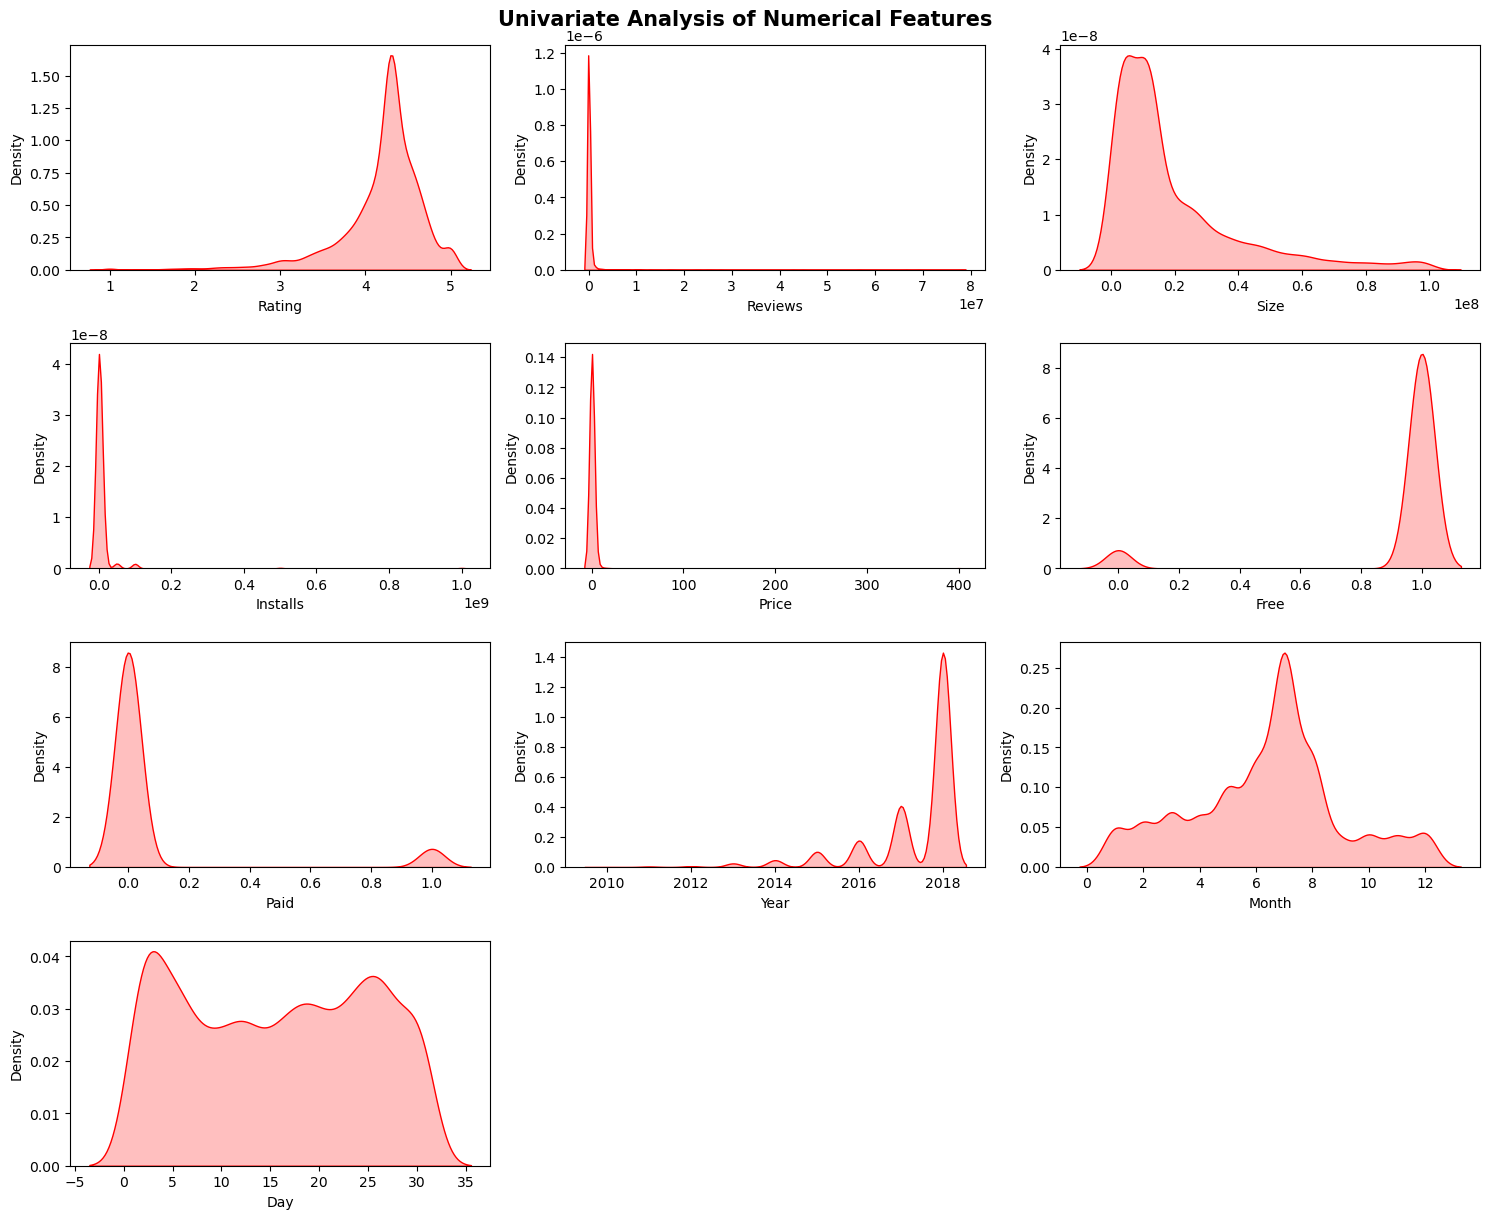

In [55]:
plt.figure(figsize=(15,15))
plt.suptitle("Univariate Analysis of Numerical Features",fontsize=15,fontweight='bold')

for i in range(0,len(numerical_features)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(df[numerical_features[i]],fill=True,color='r')
    plt.xlabel(numerical_features[i])
    plt.tight_layout()
plt.show()

Insight:- 
1. Reviews, Size, Installs, Price, Paid are 'Left Skrewed' while Rating, Free, Year are 'Right Skrewed'
2. Month and Day features are more spread in their distribution

### 6.4. Correlation between Numerical Features

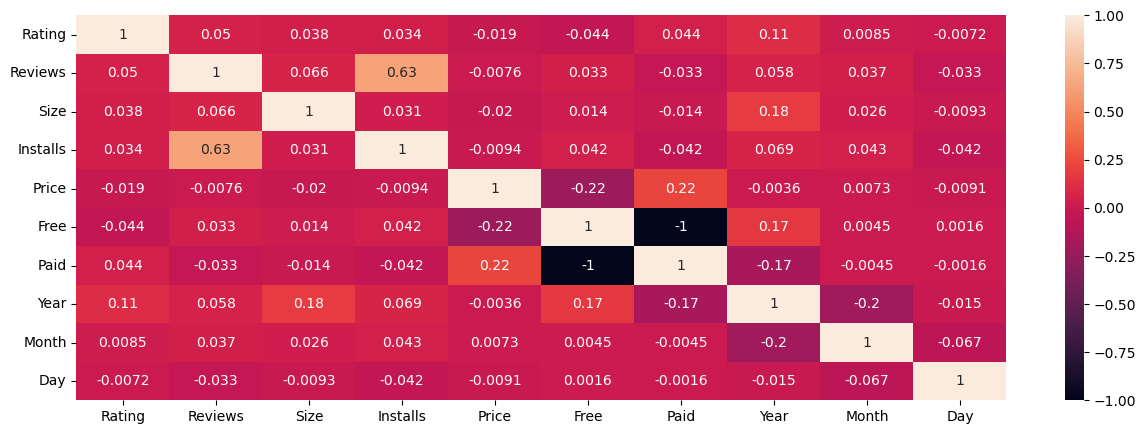

In [56]:
# Heatmap
corr = df[numerical_features].corr()
plt.figure(figsize=(15,5))
sns.heatmap(corr, annot=True)
plt.show()

Insight:- Notable positive correlations are between Installs and Reviews (0.63) & Paid and Price (0.22). Rest of them are insignificant 

### 6.5. General Overview

In [57]:
print("Number of apps in the dataset: ",df['App'].nunique())

print("Number of categories in the dataset: ",df['Category'].nunique())

print("10 Common App Categories:- \n", df['Category'].value_counts().head(10))

Number of apps in the dataset:  9659
Number of categories in the dataset:  33
10 Common App Categories:- 
 Category
FAMILY             1832
GAME                959
TOOLS               827
BUSINESS            420
MEDICAL             395
PERSONALIZATION     376
PRODUCTIVITY        374
LIFESTYLE           369
FINANCE             345
SPORTS              325
Name: count, dtype: int64


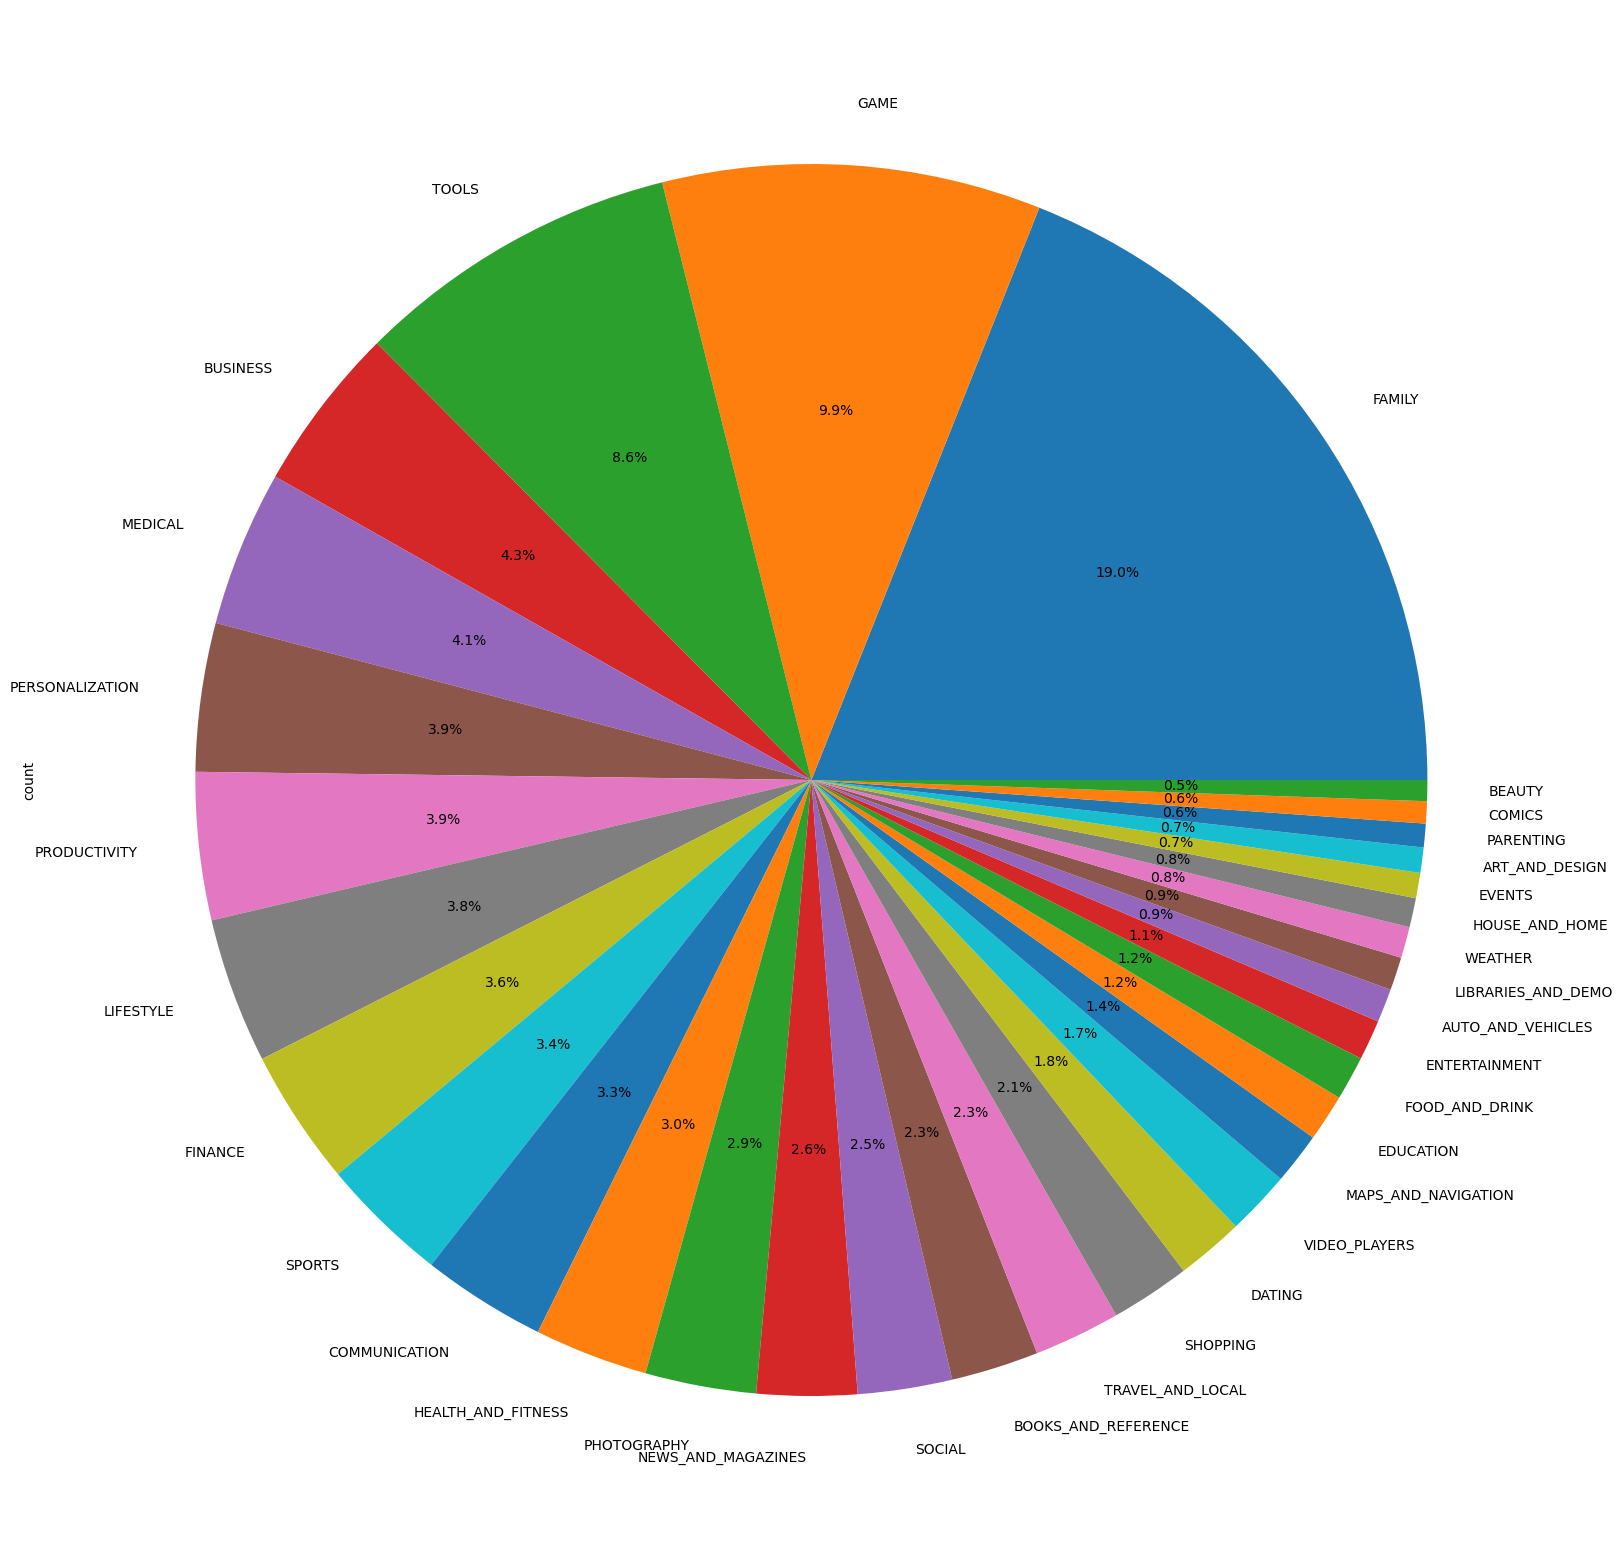

In [58]:
# Pie chart visualization
plt.show(df['Category'].value_counts().plot.pie(y=df['Category'],figsize=(20,20),autopct="%1.1f%%"))

Insight:- So, 'FAMILY' is the most popular app category, with 'GAME' and 'TOOLS' categories being second and third most.

### 6.5. Analysing Popularity and Engagement

In [59]:
category = df['Category'].unique()
category

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION'],
      dtype=object)

In [60]:
# Top 10 Apps with maximum number of installs in each category
for cat in category:
    d = df.sort_values('Installs',ascending=False)
    d = d[d['Category']==cat][['App','Installs']].reset_index(drop=True)
    print('\n CATEGORY: ',cat,'\n')
    print(d.head(10))
    print('\n')


 CATEGORY:  ART_AND_DESIGN 

                                                 App  Installs
0                              Sketch - Draw & Paint  50000000
1                         Textgram - write on photos  10000000
2  Canva: Poster, banner, card maker & graphic de...  10000000
3                     Tattoo Name On My Photo Editor  10000000
4                                       ibis Paint X  10000000
5                      FlipaClip - Cartoon animation   5000000
6                                 Floor Plan Creator   5000000
7  U Launcher Lite – FREE Live Cool Themes, Hide ...   5000000
8            Name Art Photo Editor - Focus n Filters   1000000
9                            Text on Photo - Fonteee   1000000



 CATEGORY:  AUTO_AND_VEHICLES 

                                                 App  Installs
0                      AutoScout24 - used car finder  10000000
1      Android Auto - Maps, Media, Messaging & Voice  10000000
2                                 Ulysse Speedometer 

In [61]:
# Top 10 Highly Reviewed Apps in each category
for cat in category:
    d = df.sort_values('Reviews',ascending=False)
    d = d[d['Category']==cat][['App','Reviews']].reset_index(drop=True)
    print('\n CATEGORY: ',cat,'\n')
    print(d.head(10))
    print('\n')


 CATEGORY:  ART_AND_DESIGN 

                                                 App  Reviews
0                         Textgram - write on photos   295221
1                                       ibis Paint X   224399
2                              Sketch - Draw & Paint   215644
3                      FlipaClip - Cartoon animation   194216
4  Canva: Poster, banner, card maker & graphic de...   174531
5  U Launcher Lite – FREE Live Cool Themes, Hide ...    87510
6                     Tattoo Name On My Photo Editor    44829
7                                   Infinite Painter    36815
8                                 Floor Plan Creator    36639
9                      Colorfit - Drawing & Coloring    20260



 CATEGORY:  AUTO_AND_VEHICLES 

                                                 App  Reviews
0      Android Auto - Maps, Media, Messaging & Voice   271920
1                            Tickets + PDA 2018 Exam   197136
2                      AutoScout24 - used car finder   186648
3  Fi

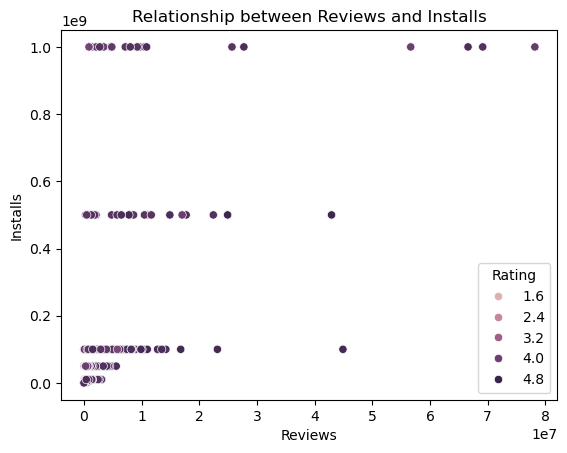

In [62]:
#Relationship between Reviews and Installs
sns.scatterplot(x='Reviews',y='Installs',data=df, hue='Rating')
plt.title('Relationship between Reviews and Installs')
plt.xlabel('Reviews')
plt.ylabel('Installs')
plt.show()

Insight:- 
1. Very Few apps are getting more than 10 million reviews.  
2. Majority of apps have less than 1 billion installs.
2. Handful of apps are getting very high number of installs and reviews, in comparison to rest

### 6.6. Monetization of Apps

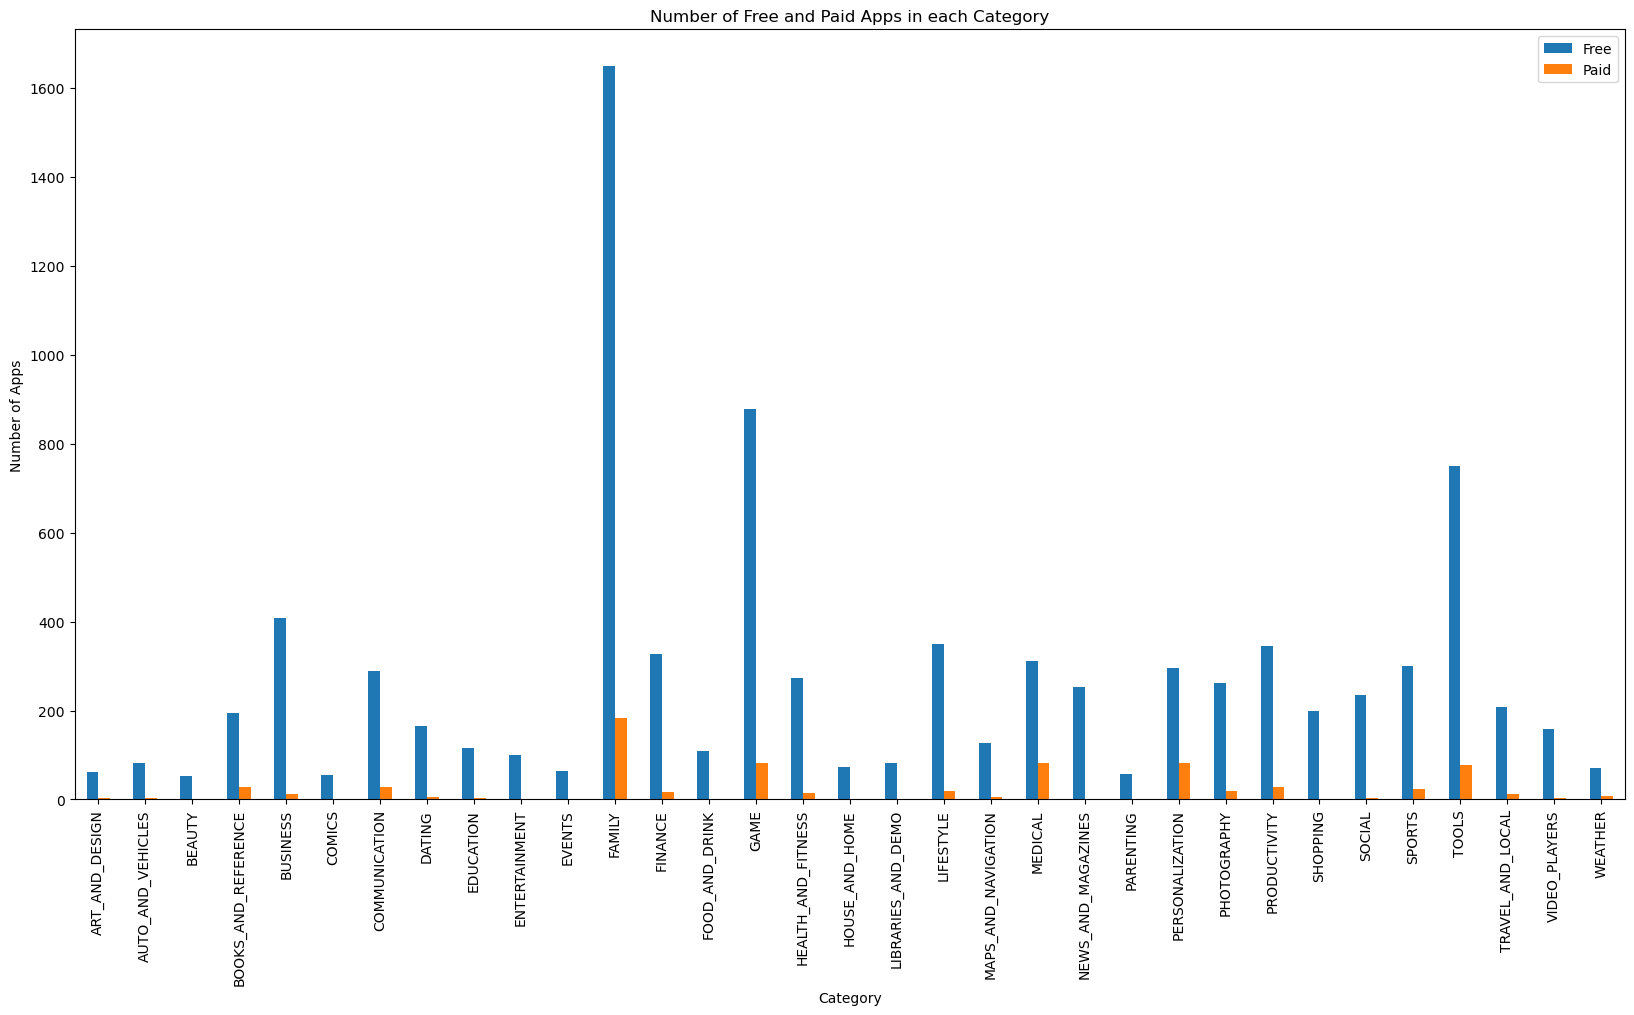

In [63]:
# Number of Free and Paid Apps in each Category
df.groupby(['Category'])[['Free','Paid']].sum().plot(kind='bar',figsize=(20,10),title='Number of Free and Paid Apps in each Category')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.show()

Insight:- In each category, we can see that the number of free apps is much higher than paid apps.

In [64]:
# Top 25 most expensive apps
df.sort_values('Price',ascending=False)[['App','Price']].head(25)

,App,Price
3469,I'm Rich - Trump Edition,400.00
8780,I'm Rich/Eu sou Rico/أنا غني/我很有錢,399.99
4403,I am rich(premium),399.99
4402,I am Rich!,399.99
4417,I AM RICH PRO PLUS,399.99
4400,I Am Rich Premium,399.99
4398,I am Rich Plus,399.99
4408,I am rich (Most expensive app),399.99
4413,I am Rich,399.99
4396,I am rich,399.99


In [65]:
# Do paid apps have higher ratings than free apps?
average_rating_free = df[df['Free']==1]['Rating'].mean()
average_rating_paid = df[df['Paid']==1]['Rating'].mean()
print("Average Rating of Free Apps: ",average_rating_free)
print("Average Rating of Paid Apps: ",average_rating_paid)

Average Rating of Free Apps:  4.186049646186678
Average Rating of Paid Apps:  4.267724867724867


Insight:- On average, paid apps have higher ratings than free apps. However, the difference is not significant.

### 6.7. User Targeting of Apps

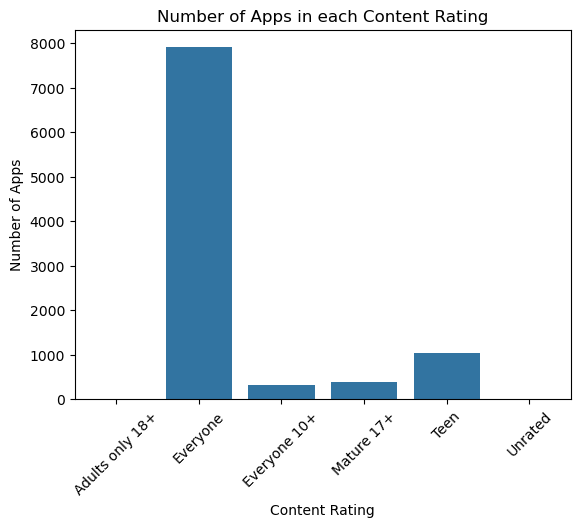

In [66]:
sns.barplot(df.groupby('Content Rating')['App'].count())
plt.title('Number of Apps in each Content Rating')
plt.xlabel('Content Rating')
plt.xticks(rotation=45)
plt.ylabel('Number of Apps')
plt.show()

Almost all apps have a content rating of 'Everyone' and 'Teen'.

### 6.8 Multivariate Analysis

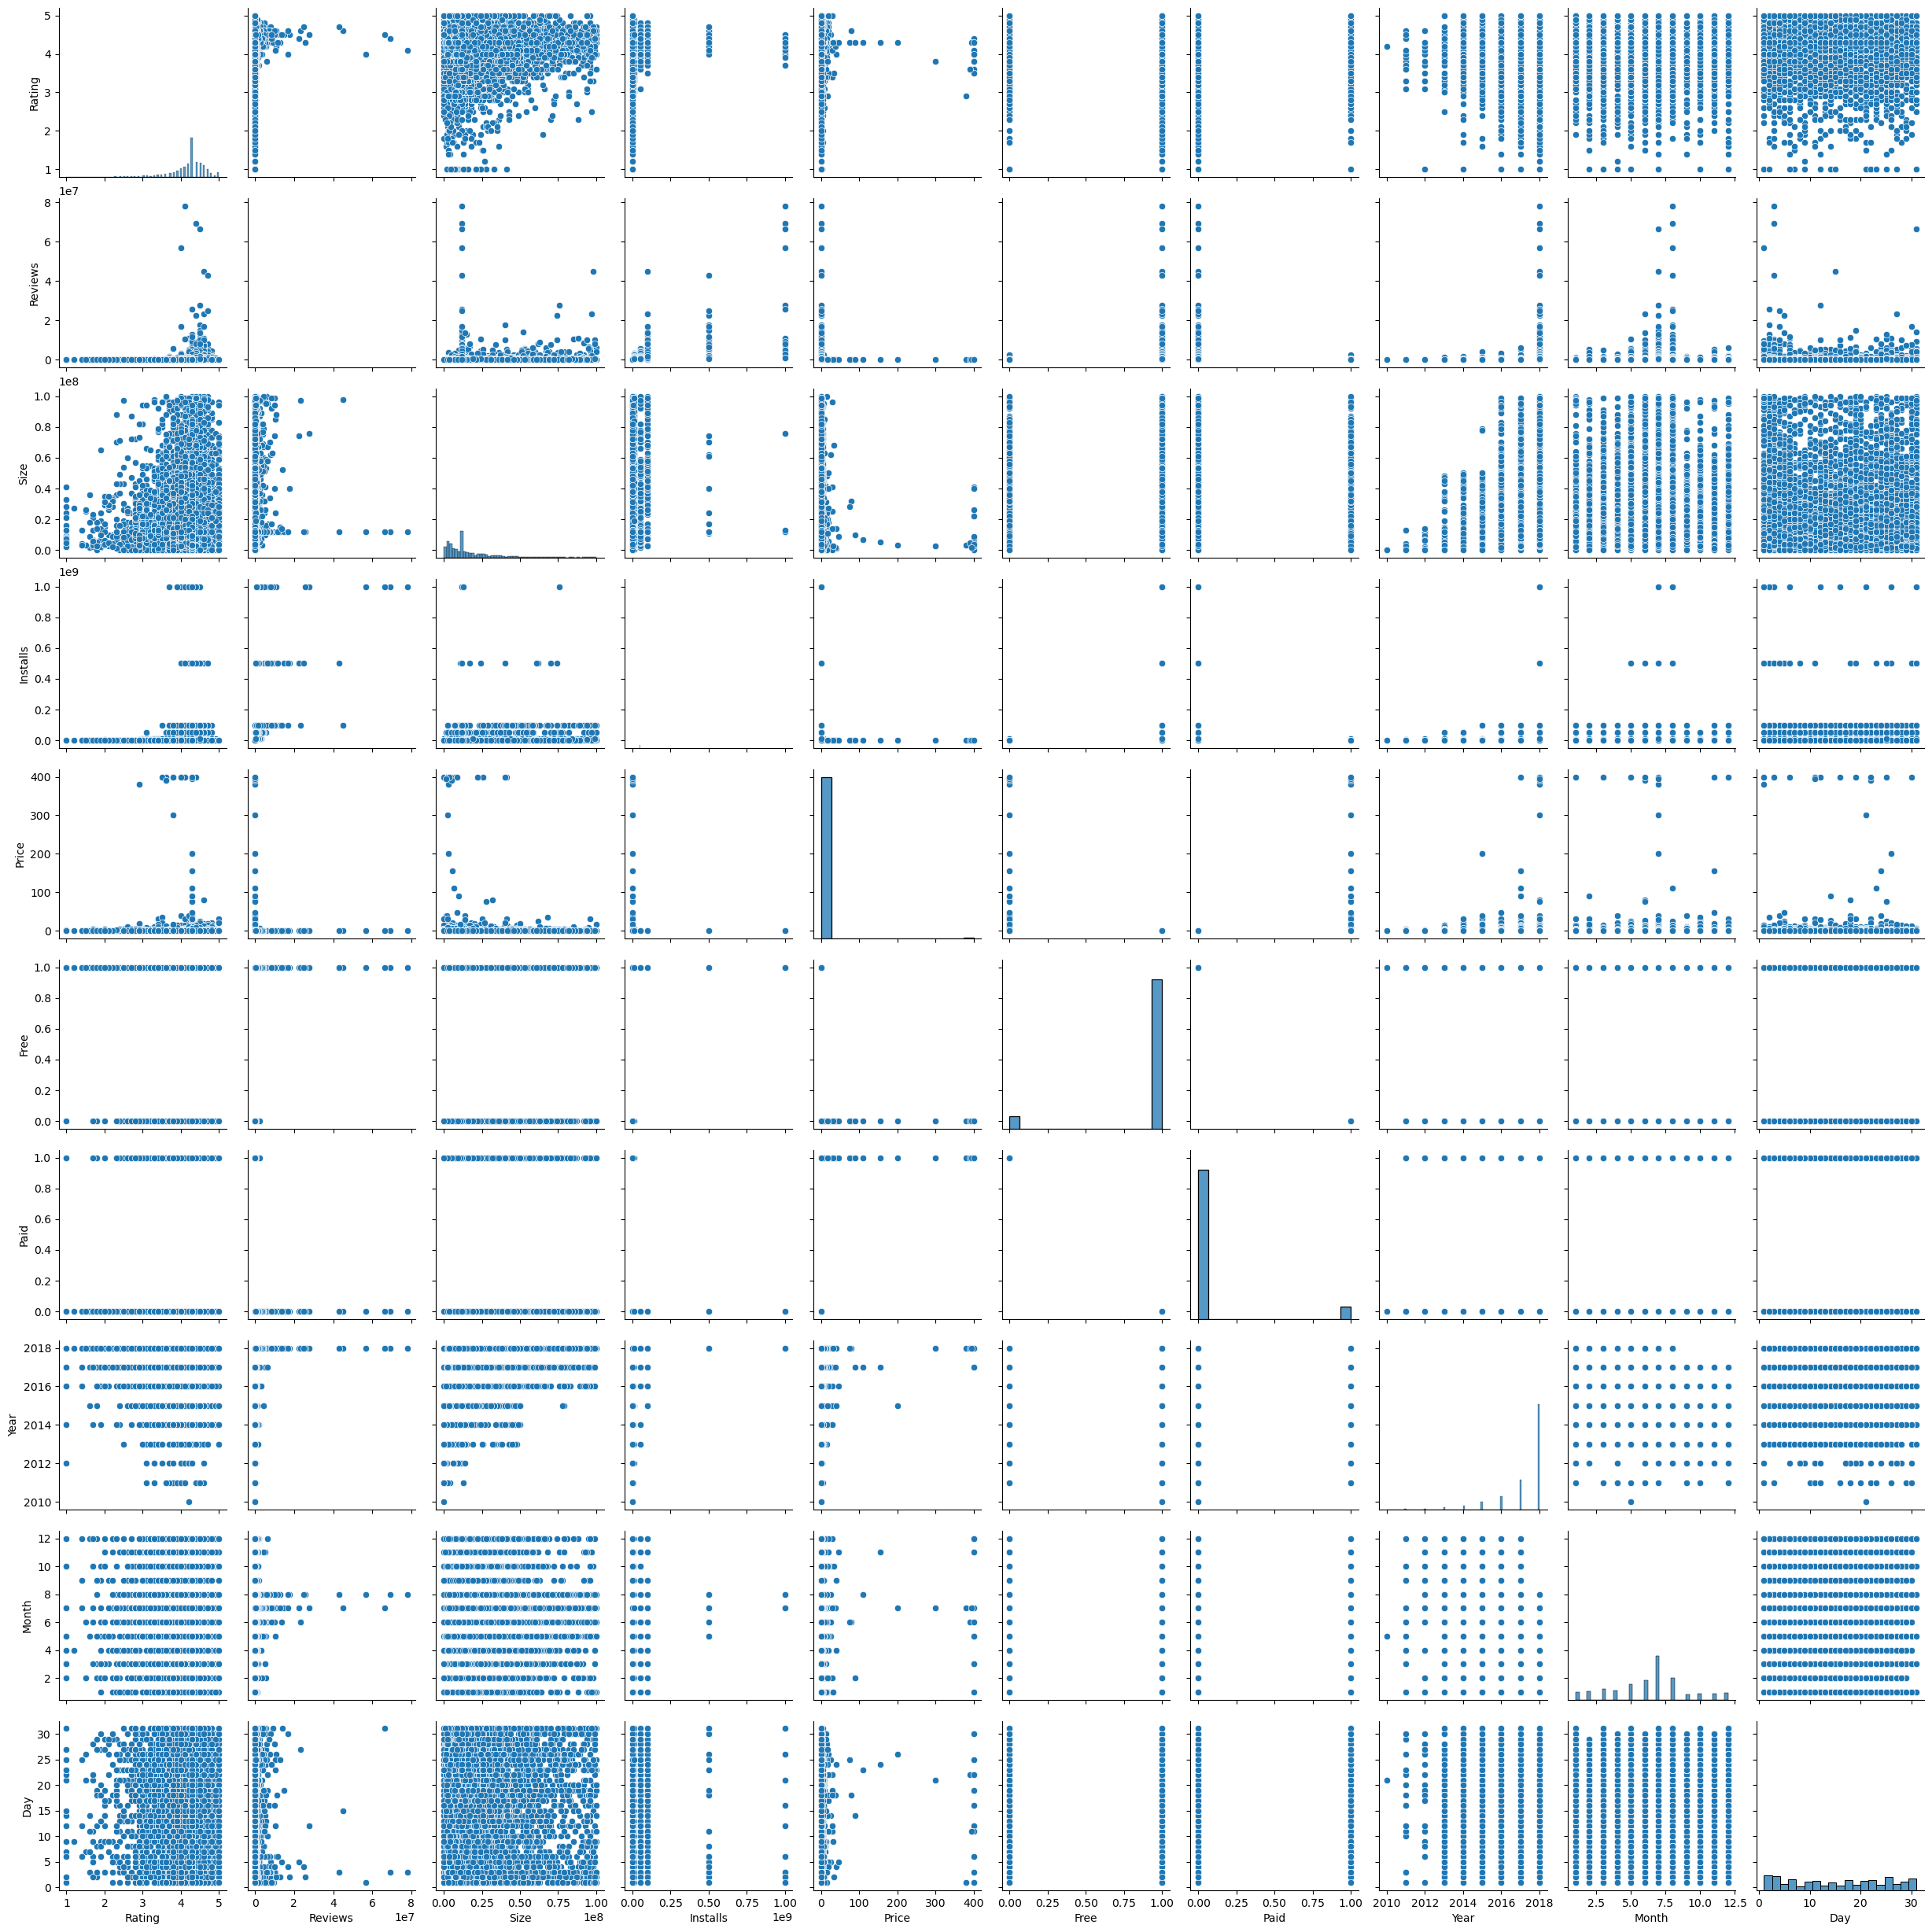

In [67]:
sns.pairplot(df)
plt.show()